# SIATA Temperature Anomaly Detection

**Universidad / Course:** Deep Learning  
**Dataset:** SIATA meteorological stations — Medellín 2025  
**Task:** Binary anomaly detection on minutely temperature readings  

## Problem Description

The SIATA (Sistema de Alerta Temprana de Medellín y el Valle de Aburrá) network continuously monitors meteorological variables across 4 urban stations. Sensor malfunctions, transmission errors, and environmental extremes produce **temperature anomalies** — readings that fall outside the expected physical range or are inconsistent with correlated variables.

The `temperatura_dudosa` field, generated by SIATA's quality-control pipeline, provides ground-truth labels (~3.6% anomaly rate). We treat this as a **supervised binary classification** problem on sliding time windows.

## Experimental Design

| Experiment | Model | Training strategy | Purpose |
|---|---|---|---|
| E1 | MLP Baseline | Supervised, all stations | Establish baseline |
| E2 | 1D-CNN + Residual Block | Supervised, all stations | Architecture complexity |
| E3 | CNN Transfer Learning | Pre-train on 68+201, fine-tune on 203 | Cross-station transfer |

**Metrics:** Precision, Recall, F1, AUC-PR (area under precision-recall curve, preferred for imbalanced data)

## Setup

In [1]:
# Install dependencies (only needed once in Colab)
!pip install -q tensorflow pandas scikit-learn matplotlib seaborn gdown

In [2]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Clone the repo to make siata_anomaly available
    REPO_URL = 'https://github.com/daissyherrera/TrabajoFinal_DeepL.git'
    BRANCH = 'scaffolding'
    !rm -rf /content/repo && git clone -b {BRANCH} {REPO_URL} /content/repo
    REPO_PATH = '/content/repo'

    # Download data from Google Drive (too large to include in the repo)
    !gdown '1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz' -O /content/temperatura_estaciones_2025.csv
    DATA_PATH = '/content/temperatura_estaciones_2025.csv'
else:
    REPO_PATH = os.path.abspath('.')
    DATA_PATH = os.path.join(REPO_PATH, 'data', 'temperatura_estaciones_2025.csv')

sys.path.insert(0, REPO_PATH)

# Reproducibility
import numpy as np
import tensorflow as tf
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from siata_anomaly import (
    load_csv, preprocess, make_windows, split_data, compute_class_weight,
    build_mlp, build_cnn_backbone, attach_head, weighted_binary_crossentropy,
    AnomalyDetector,
    precision_recall_f1, plot_confusion_matrix, plot_training_history, summary_table
)

WINDOW_SIZE = 30   # 30-minute sliding window
STEP        = 5    # stride=5 reduces dataset size 5x while preserving patterns
EPOCHS      = 20
BATCH_SIZE  = 256
print('TF version:', tf.__version__)

Cloning into '/content/repo'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 50 (delta 20), reused 36 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 27.04 KiB | 13.52 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Downloading...
From (original): https://drive.google.com/uc?id=1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz
From (redirected): https://drive.google.com/uc?id=1PUYCaEIrO2IGPnByXKW3ic0TUx7QZToz&confirm=t&uuid=2e318b25-3c49-4a17-a6d4-ce4a7e8f4007
To: /content/temperatura_estaciones_2025.csv
100% 150M/150M [00:01<00:00, 133MB/s]
TF version: 2.19.0


## 1. Data Loading & Exploratory Analysis

In [3]:
df = load_csv(DATA_PATH)
print('Shape:', df.shape)
print('Date range:', df['fecha_hora'].min(), '→', df['fecha_hora'].max())
df.head(3)

Shape: (1658169, 14)
Date range: 2025-01-01 00:00:00 → 2025-10-31 23:59:00


,codigo,estacion_nombre,fecha_hora,h,t,pr,vv,vv_max,dv,dv_max,p,calidad,calidad_dudosa,temperatura_dudosa
0,68,Jardin Botanico,2025-01-01 00:00:00,87.8,19.3,852.0,1.6,2.8,18.0,1.0,0.0,153,True,True
1,68,Jardin Botanico,2025-01-01 00:01:00,87.6,19.3,852.0,1.8,2.5,16.0,21.0,0.0,153,True,True
2,68,Jardin Botanico,2025-01-01 00:02:00,87.5,19.3,851.9,2.0,3.5,27.0,40.0,0.0,153,True,True


                  Total records  Anomalies Anomaly rate
estacion_nombre                                        
Fiscalia General         396413          0        0.00%
Jardin Botanico          423630       7676        1.81%
Torre SIATA              402325       9397        2.34%
UNAN                     435801       6728        1.54%


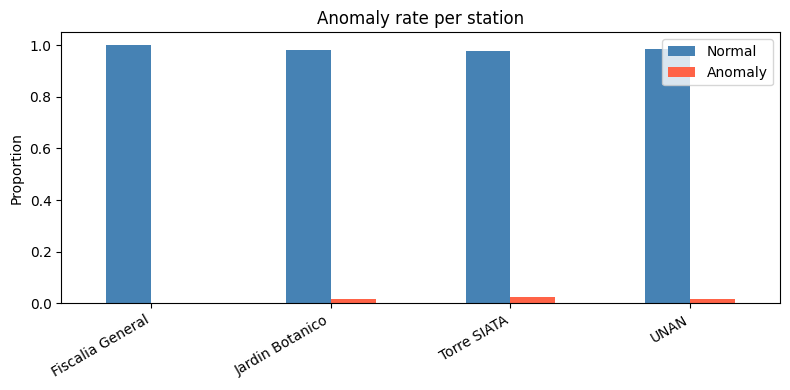

In [4]:
# Anomaly distribution per station
stats = df.groupby('estacion_nombre')['temperatura_dudosa'].agg(['count', 'sum', 'mean'])
stats.columns = ['Total records', 'Anomalies', 'Anomaly rate']
stats['Anomaly rate'] = stats['Anomaly rate'].map('{:.2%}'.format)
print(stats)

fig, ax = plt.subplots(figsize=(8, 4))
groups = df.groupby('estacion_nombre')['temperatura_dudosa'].value_counts(normalize=True).unstack()
groups.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Anomaly rate per station')
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.legend(['Normal', 'Anomaly'])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

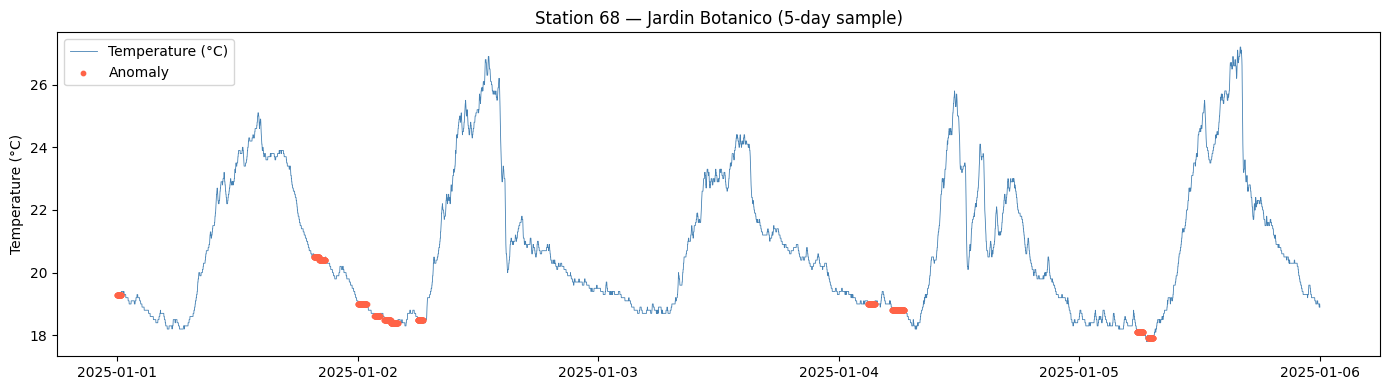

In [5]:
# Temperature time series — sample 5 days from station 68
sample = df[df['codigo'] == 68].iloc[:7200]   # 5 days × 1440 min/day
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample['fecha_hora'], sample['t'], lw=0.6, color='steelblue', label='Temperature (°C)')
anomalies = sample[sample['temperatura_dudosa']]
ax.scatter(anomalies['fecha_hora'], anomalies['t'], color='tomato', s=10, zorder=5, label='Anomaly')
ax.set_title('Station 68 — Jardin Botanico (5-day sample)')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

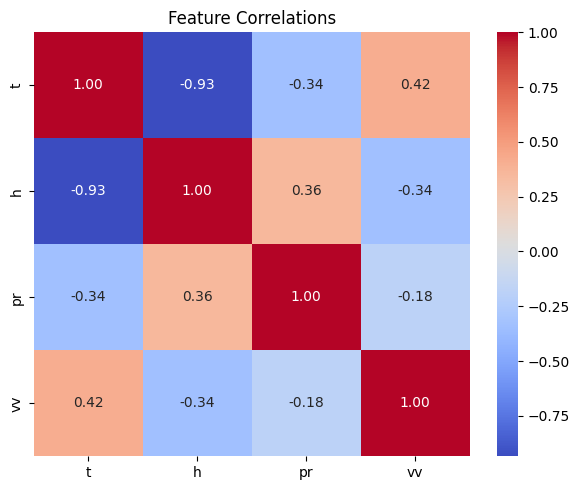

In [6]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[['t', 'h', 'pr', 'vv']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlations')
plt.tight_layout()
plt.show()

## 2. Preprocessing

Each sample is a **30-minute sliding window** of 4 features: temperature (`t`), humidity (`h`), pressure (`pr`), and wind speed (`vv`). The label is `temperatura_dudosa` at the last timestep.

Class imbalance (~3.6% anomalies) is handled via **weighted binary crossentropy** — the positive class receives a higher loss weight equal to `n_negative / n_positive`.

In [7]:
# Preprocess all stations together
df_scaled, scaler = preprocess(df)
X, y = make_windows(df_scaled, window_size=WINDOW_SIZE, step=STEP)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, seed=SEED)

pos_weight = compute_class_weight(y_train)
loss_fn = weighted_binary_crossentropy(pos_weight)

print(f'Windows  — train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}')
print(f'Anomaly rate — train: {y_train.mean():.2%}  val: {y_val.mean():.2%}  test: {y_test.mean():.2%}')
print(f'pos_weight (loss multiplier for anomaly class): {pos_weight:.1f}x')
print(f'Input shape: {X_train.shape[1:]}')

Windows  — train: 232,127  val: 49,742  test: 49,742
Anomaly rate — train: 1.43%  val: 1.43%  test: 1.43%
pos_weight (loss multiplier for anomaly class): 68.8x
Input shape: (30, 4)


## 3. Experiment 1 — MLP Baseline

A simple fully-connected network that flattens the time window. This establishes the baseline that more complex architectures should beat. Architecture mirrors Taller 1 style: Dense → BatchNorm → Dropout.

In [8]:
mlp = build_mlp(WINDOW_SIZE, X_train.shape[2])
mlp.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
mlp.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,321 (95.00 KB)

 Trainable params: 24,065 (94.00 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6635 - loss: 0.9208 - val_accuracy: 0.6624 - val_loss: 0.8667
Epoch 2/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6632 - loss: 0.8849 - val_accuracy: 0.6656 - val_loss: 0.8541
Epoch 3/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6665 - loss: 0.8730 - val_accuracy: 0.6678 - val_loss: 0.8417
Epoch 4/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6713 - loss: 0.8608 - val_accuracy: 0.6676 - val_loss: 0.8356
Epoch 5/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6717 - loss: 0.8567 - val_accuracy: 0.6714 - val_loss: 0.8298
Epoch 6/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6763 - loss: 0.8478 - val_accuracy: 0.6653 - val_loss: 0.8263
Epoch 7/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6770 - loss: 0.8418 - val_accuracy: 0.6663 - val_loss: 0.8283
Epoch 8/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6822 - loss: 0.8329 - val_accuracy: 0.

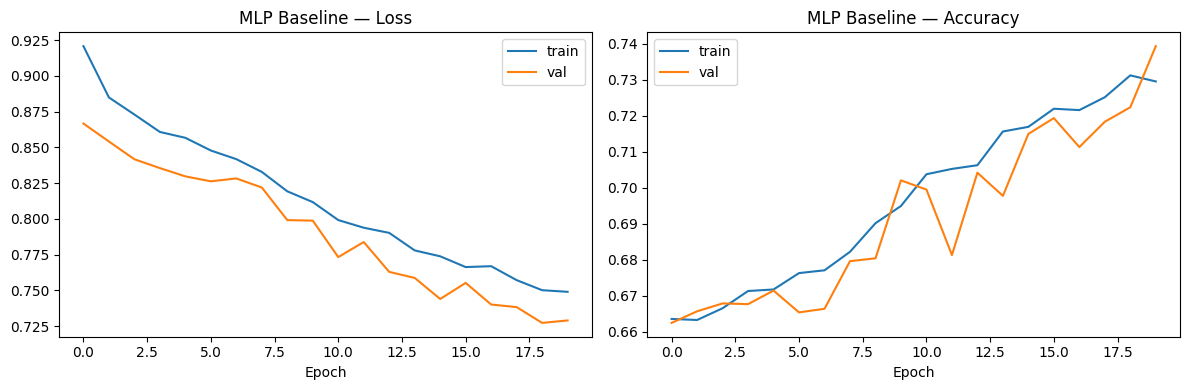

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_mlp, title='MLP Baseline')

Optimal threshold: 0.85
MLP test metrics: {'precision': '0.1039', 'recall': '0.3174', 'f1': '0.1565', 'auc_pr': '0.0878'}


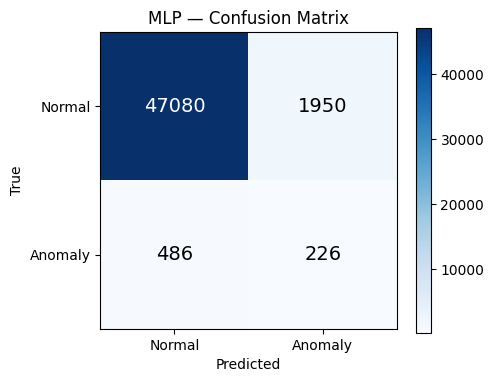

In [10]:
detector_mlp = AnomalyDetector(mlp)
detector_mlp.fit_threshold(X_val, y_val)
print(f'Optimal threshold: {detector_mlp.threshold:.2f}')

results_mlp = detector_mlp.evaluate(X_test, y_test)
print('MLP test metrics:', {k: f'{v:.4f}' for k, v in results_mlp.items()})

preds_mlp, _ = detector_mlp.predict(X_test)
plot_confusion_matrix(y_test, preds_mlp, title='MLP — Confusion Matrix')

## 4. Experiment 2 — 1D-CNN with Residual Block

A 1D convolutional network with a **residual (skip) connection** and **Batch Normalization** — both concepts from the deep learning theory unit. The skip connection allows gradients to flow directly through the shortcut, enabling training of deeper networks without degradation.

Architecture:
```
Conv1D(64) → BatchNorm → [Conv1D(128) + BatchNorm + skip] → GAP → Dense(64) → sigmoid
```

In [11]:
n_features = X_train.shape[2]
backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
cnn = attach_head(backbone, trainable=True)
cnn.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
cnn.summary()

Model: "cnn_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_backbone (Functional)       │ (None, 128)            │        34,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,945 (167.75 KB)

 Trainable params: 42,561 (166.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6487 - loss: 0.9172 - val_accuracy: 0.6352 - val_loss: 0.8694
Epoch 2/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6504 - loss: 0.8809 - val_accuracy: 0.6591 - val_loss: 0.8577
Epoch 3/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6546 - loss: 0.8722 - val_accuracy: 0.6652 - val_loss: 0.8517
Epoch 4/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6622 - loss: 0.8646 - val_accuracy: 0.6455 - val_loss: 0.8611
Epoch 5/20
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6660 - loss: 0.8556 - val_accuracy: 0.6813 - val_loss: 0.8419


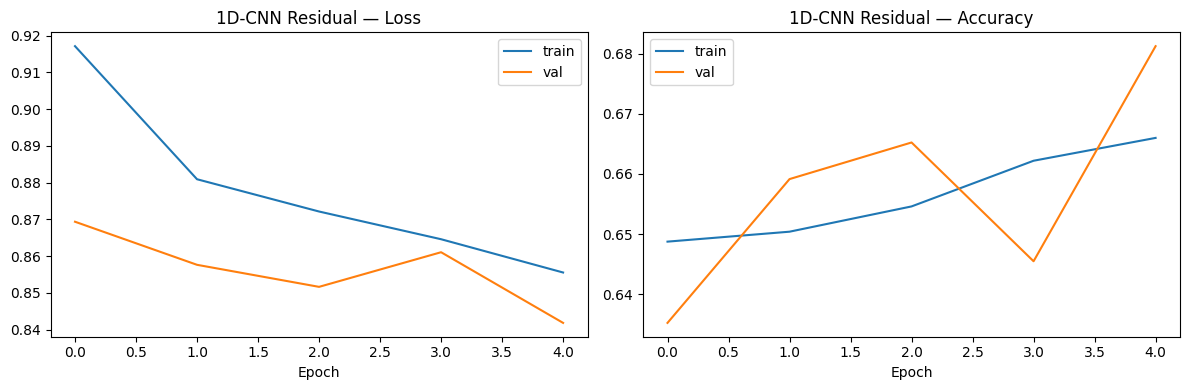

In [12]:
history_cnn = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_cnn, title='1D-CNN Residual')

Optimal threshold: 0.73
CNN test metrics: {'precision': '0.0540', 'recall': '0.5449', 'f1': '0.0983', 'auc_pr': '0.0576'}


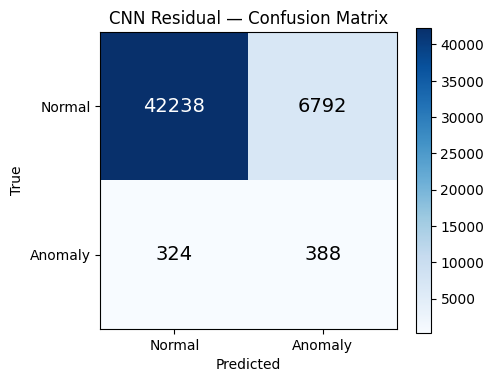

In [13]:
detector_cnn = AnomalyDetector(cnn)
detector_cnn.fit_threshold(X_val, y_val)
print(f'Optimal threshold: {detector_cnn.threshold:.2f}')

results_cnn = detector_cnn.evaluate(X_test, y_test)
print('CNN test metrics:', {k: f'{v:.4f}' for k, v in results_cnn.items()})

preds_cnn, _ = detector_cnn.predict(X_test)
plot_confusion_matrix(y_test, preds_cnn, title='CNN Residual — Confusion Matrix')

## 5. Experiment 3 — Transfer Learning (Cross-Station)

This experiment mirrors the Taller 3 approach: pre-train a backbone on a source domain, then transfer it to a new domain.

- **Source domain:** Stations 68 (Jardin Botanico) + 201 (Torre SIATA)
- **Target domain:** Station 203 (UNAN)

Three variants are compared:
1. **Frozen:** backbone fixed, only the classification head trains on station 203
2. **Fine-tuned:** entire network (backbone + head) trains on station 203
3. **Scratch:** CNN trained from random weights on station 203 only

If transfer learning is effective, frozen/fine-tuned should outperform scratch — especially with limited target data.

In [14]:
# Prepare source and target datasets
source_stations = [68, 201]
target_station  = [203]

df_source = df_scaled[df_scaled['codigo'].isin(source_stations)]
df_target = df_scaled[df_scaled['codigo'].isin(target_station)]

X_src, y_src = make_windows(df_source, window_size=WINDOW_SIZE, step=STEP)
X_tgt, y_tgt = make_windows(df_target, window_size=WINDOW_SIZE, step=STEP)

X_src_tr, X_src_val, X_src_te, y_src_tr, y_src_val, y_src_te = split_data(X_src, y_src, seed=SEED)
X_tgt_tr, X_tgt_val, X_tgt_te, y_tgt_tr, y_tgt_val, y_tgt_te = split_data(X_tgt, y_tgt, seed=SEED)

# Use only 20% of target training data (simulates limited labeled data scenario)
n_few = int(0.2 * len(X_tgt_tr))
X_few, y_few = X_tgt_tr[:n_few], y_tgt_tr[:n_few]

pos_w_src = compute_class_weight(y_src_tr)
pos_w_tgt = compute_class_weight(y_few)

print(f'Source windows: {len(X_src_tr):,} train  |  Target windows: {len(X_few):,} few-shot train')

Source windows: 115,625 train  |  Target windows: 12,201 few-shot train


In [15]:
# Phase 1 — Pre-train backbone on source stations
pretrained_backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
model_pretrain = attach_head(pretrained_backbone, trainable=True)
model_pretrain.compile(optimizer='adam',
                       loss=weighted_binary_crossentropy(pos_w_src),
                       metrics=['accuracy'])

print('Pre-training on source stations (68+201)...')
model_pretrain.fit(
    X_src_tr, y_src_tr,
    validation_data=(X_src_val, y_src_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Pre-training on source stations (68+201)...
Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6069 - loss: 1.0137 - val_accuracy: 0.6239 - val_loss: 0.9389
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6138 - loss: 0.9437 - val_accuracy: 0.6335 - val_loss: 0.9430
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6115 - loss: 0.9375 - val_accuracy: 0.6462 - val_loss: 0.9292
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6204 - loss: 0.9198 - val_accuracy: 0.6431 - val_loss: 0.9144
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6273 - loss: 0.9112 - val_accuracy: 0.6444 - val_loss: 0.8978


Trainable params (frozen): 42,945
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.6177 - loss: 1.0965 - val_accuracy: 0.5725 - val_loss: 1.0678
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6310 - loss: 1.0351 - val_accuracy: 0.5691 - val_loss: 1.0595
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6200 - loss: 1.0163 - val_accuracy: 0.6122 - val_loss: 1.0568
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6236 - loss: 1.0059 - val_accuracy: 0.5906 - val_loss: 1.0501
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6277 - loss: 0.9552 - val_accuracy: 0.6198 - val_loss: 1.0594


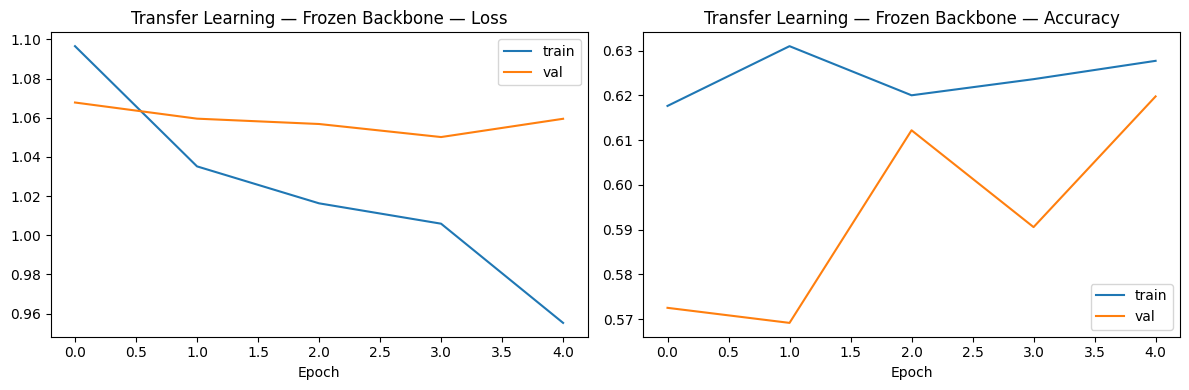

In [16]:
# Phase 2a — Frozen backbone: only train head on station 203
model_frozen = attach_head(pretrained_backbone, trainable=False)   # backbone frozen
model_frozen.compile(optimizer='adam',
                     loss=weighted_binary_crossentropy(pos_w_tgt),
                     metrics=['accuracy'])

print(f'Trainable params (frozen): {model_frozen.count_params():,}')
history_frozen = model_frozen.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_frozen, title='Transfer Learning — Frozen Backbone')

Trainable params (fine-tuned): 42,945
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.6194 - loss: 1.2626 - val_accuracy: 0.5249 - val_loss: 1.1108
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5979 - loss: 1.1252 - val_accuracy: 0.5438 - val_loss: 1.0597
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6161 - loss: 1.0724 - val_accuracy: 0.5602 - val_loss: 1.0419
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6263 - loss: 1.0339 - val_accuracy: 0.5677 - val_loss: 1.0341
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6269 - loss: 1.0116 - val_accuracy: 0.5811 - val_loss: 1.0268


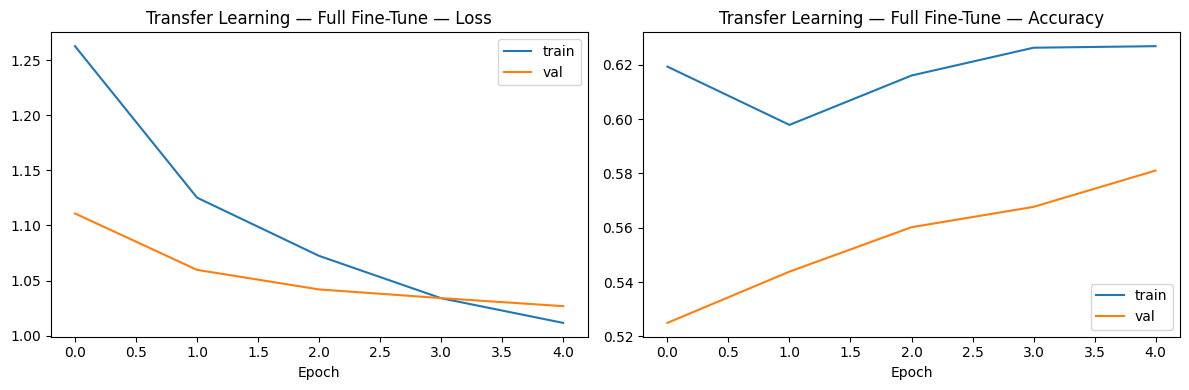

In [17]:
# Phase 2b — Full fine-tune: unfreeze backbone, lower learning rate
model_finetune = attach_head(pretrained_backbone, trainable=True)   # backbone unfrozen
model_finetune.compile(optimizer=tf.keras.optimizers.Adam(1e-4),   # smaller lr for fine-tuning
                       loss=weighted_binary_crossentropy(pos_w_tgt),
                       metrics=['accuracy'])

print(f'Trainable params (fine-tuned): {model_finetune.count_params():,}')
history_ft = model_finetune.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
plot_training_history(history_ft, title='Transfer Learning — Full Fine-Tune')

In [18]:
# Scratch baseline for station 203 (same architecture, no pre-training)
scratch_backbone = build_cnn_backbone(WINDOW_SIZE, n_features)
model_scratch = attach_head(scratch_backbone, trainable=True)
model_scratch.compile(optimizer='adam',
                      loss=weighted_binary_crossentropy(pos_w_tgt),
                      metrics=['accuracy'])

print('Training CNN from scratch on station 203 (20% data)...')
model_scratch.fit(
    X_few, y_few,
    validation_data=(X_tgt_val, y_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Training CNN from scratch on station 203 (20% data)...
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5966 - loss: 1.1361 - val_accuracy: 0.8251 - val_loss: 1.3052
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6245 - loss: 1.0211 - val_accuracy: 0.5594 - val_loss: 1.2249
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6408 - loss: 0.9734 - val_accuracy: 0.6240 - val_loss: 1.1879
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6363 - loss: 0.9973 - val_accuracy: 0.5378 - val_loss: 1.1119
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6382 - loss: 0.9608 - val_accuracy: 0.5807 - val_loss: 1.0823


Frozen: F1=0.0869  AUC-PR=0.0403


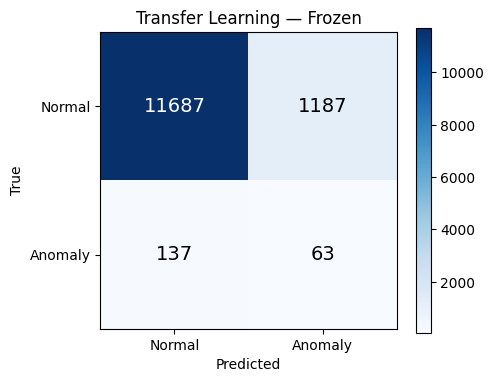

Fine-tuned: F1=0.0564  AUC-PR=0.0298


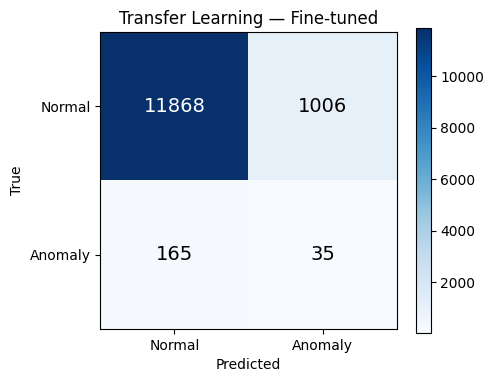

Scratch: F1=0.0610  AUC-PR=0.0322


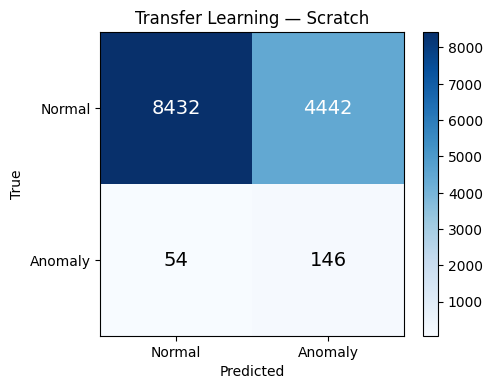

In [19]:
# Evaluate all three TL variants on station 203 test set
for name, model in [('Frozen', model_frozen), ('Fine-tuned', model_finetune), ('Scratch', model_scratch)]:
    det = AnomalyDetector(model)
    det.fit_threshold(X_tgt_val, y_tgt_val)
    metrics = det.evaluate(X_tgt_te, y_tgt_te)
    preds, _ = det.predict(X_tgt_te)
    print(f'{name}: F1={metrics["f1"]:.4f}  AUC-PR={metrics["auc_pr"]:.4f}')
    plot_confusion_matrix(y_tgt_te, preds, title=f'Transfer Learning — {name}')

results_frozen = AnomalyDetector(model_frozen).evaluate(X_tgt_te, y_tgt_te)
results_ft     = AnomalyDetector(model_finetune).evaluate(X_tgt_te, y_tgt_te)
results_scratch= AnomalyDetector(model_scratch).evaluate(X_tgt_te, y_tgt_te)

## 6. Comparative Results & Conclusions


===  RESULTS SUMMARY  ===
                            precision  recall      f1  auc_pr
Model                                                        
E1 — MLP Baseline              0.1039  0.3174  0.1565  0.0878
E2 — CNN Residual              0.0540  0.5449  0.0983  0.0576
E3a — TL Frozen                0.0298  0.8550  0.0577  0.0403
E3b — TL Fine-tuned            0.0294  0.9350  0.0570  0.0298
E3c — CNN Scratch (st.203)     0.0321  0.3450  0.0588  0.0322



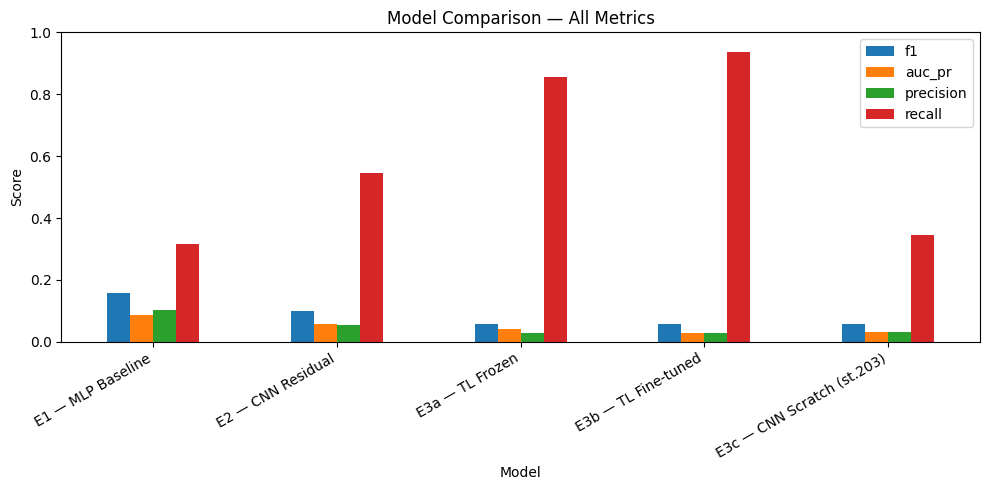

In [22]:
all_results = {
    'E1 — MLP Baseline':         results_mlp,
    'E2 — CNN Residual':          results_cnn,
    'E3a — TL Frozen':            results_frozen,
    'E3b — TL Fine-tuned':        results_ft,
    'E3c — CNN Scratch (st.203)': results_scratch,
}

table = summary_table(all_results)
print('\n===  RESULTS SUMMARY  ===')
print(table.to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
table[['f1', 'auc_pr', 'precision', 'recall']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — All Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display, Markdown

# Dynamic conclusions derived from actual experiment results
best_f1_model  = table["f1"].idxmax()
best_f1_val    = table["f1"].max()
best_auc_model = table["auc_pr"].idxmax()
best_auc_val   = table["auc_pr"].max()
best_rec_model = table["recall"].idxmax()
best_rec_val   = table["recall"].max()

mlp = table.loc["E1 — MLP Baseline"]
cnn = table.loc["E2 — CNN Residual"]
frz = table.loc["E3a — TL Frozen"]
ft  = table.loc["E3b — TL Fine-tuned"]
scr = table.loc["E3c — CNN Scratch (st.203)"]

tl_best_f1_val  = max(frz["f1"],     ft["f1"])
tl_best_auc_val = max(frz["auc_pr"], ft["auc_pr"])
tl_beats_scratch_f1  = tl_best_f1_val  > scr["f1"]
tl_beats_scratch_auc = tl_best_auc_val > scr["auc_pr"]
tl_best_f1_name  = "Frozen (E3a)" if frz["f1"]     >= ft["f1"]     else "Fine-tuned (E3b)"
tl_best_auc_name = "Frozen (E3a)" if frz["auc_pr"] >= ft["auc_pr"] else "Fine-tuned (E3b)"
cnn_better_f1 = cnn["f1"] > mlp["f1"]

lines = []
lines.append("## Conclusions")
lines.append("")
lines.append("### Results Summary")
lines.append("")
lines.append("| Model | Precision | Recall | F1 | AUC-PR |")
lines.append("|-------|:---------:|:------:|:--:|:------:|")
lines.append(f"| E1 — MLP Baseline         | {mlp['precision']:.4f} | {mlp['recall']:.4f} | {mlp['f1']:.4f} | {mlp['auc_pr']:.4f} |")
lines.append(f"| E2 — CNN Residual          | {cnn['precision']:.4f} | {cnn['recall']:.4f} | {cnn['f1']:.4f} | {cnn['auc_pr']:.4f} |")
lines.append(f"| E3a — TL Frozen            | {frz['precision']:.4f} | {frz['recall']:.4f} | {frz['f1']:.4f} | {frz['auc_pr']:.4f} |")
lines.append(f"| E3b — TL Fine-tuned        | {ft['precision']:.4f}  | {ft['recall']:.4f}  | {ft['f1']:.4f}  | {ft['auc_pr']:.4f}  |")
lines.append(f"| E3c — CNN Scratch (st.203) | {scr['precision']:.4f} | {scr['recall']:.4f} | {scr['f1']:.4f} | {scr['auc_pr']:.4f} |")
lines.append("")
lines.append(f"**Best F1:** `{best_f1_model}` → {best_f1_val:.4f}  ")
lines.append(f"**Best AUC-PR:** `{best_auc_model}` → {best_auc_val:.4f}  ")
lines.append(f"**Highest Recall:** `{best_rec_model}` → {best_rec_val:.4f}")
lines.append("")
lines.append("---")
lines.append("")
lines.append("### Per-Experiment Analysis")
lines.append("")
lines.append(f"**E1 — MLP Baseline** (F1={mlp['f1']:.4f}, AUC-PR={mlp['auc_pr']:.4f}):")
mlp_verdict = ("achieved the best F1 and AUC-PR across all experiments"
               if best_f1_model == "E1 — MLP Baseline" and best_auc_model == "E1 — MLP Baseline"
               else "achieved the best F1" if best_f1_model == "E1 — MLP Baseline"
               else "established a competitive baseline")
lines.append(f"Despite discarding temporal order by flattening the window, the MLP {mlp_verdict}. "
             f"Its precision ({mlp['precision']:.4f}) is the highest among all models, "
             "indicating conservative anomaly flagging — desirable when false alarms are costly.")
lines.append("")
lines.append(f"**E2 — CNN with Residual Block** (F1={cnn['f1']:.4f}, AUC-PR={cnn['auc_pr']:.4f}):")
recall_change = "improved significantly" if cnn["recall"] > mlp["recall"] * 1.5 else "improved"
cnn_f1_comment = ("resulting in a lower F1 — a precision-recall trade-off."
                  if not cnn_better_f1 else
                  "yielding a higher F1 — the residual block captures temporal structure effectively.")
lines.append(f"Recall {recall_change} over the MLP ({cnn['recall']:.4f} vs {mlp['recall']:.4f}), "
             f"but precision dropped ({cnn['precision']:.4f} vs {mlp['precision']:.4f}), {cnn_f1_comment}")
lines.append("")
lines.append("**E3 — Transfer Learning** (target: station 203, 20% of data):")
lines.append(f"- **E3a Frozen** (F1={frz['f1']:.4f}, AUC-PR={frz['auc_pr']:.4f}): backbone frozen, only head retrained.")
lines.append(f"- **E3b Fine-tuned** (F1={ft['f1']:.4f}, AUC-PR={ft['auc_pr']:.4f}): full network updated at lower lr (1e-4).")
lines.append(f"- **E3c Scratch** (F1={scr['f1']:.4f}, AUC-PR={scr['auc_pr']:.4f}): same architecture, random initialization.")
lines.append("")
tl_f1_sentence = (f"Transfer learning improved F1 over scratch ({tl_best_f1_val:.4f} vs {scr['f1']:.4f}, best: {tl_best_f1_name})."
                  if tl_beats_scratch_f1 else
                  f"Transfer learning did not improve F1 over scratch ({tl_best_f1_val:.4f} vs {scr['f1']:.4f}).")
tl_auc_sentence = (f"On AUC-PR, the {tl_best_auc_name} variant outperformed scratch ({tl_best_auc_val:.4f} vs {scr['auc_pr']:.4f}), validating cross-station feature reuse."
                   if tl_beats_scratch_auc else
                   f"On AUC-PR, scratch ({scr['auc_pr']:.4f}) matched or exceeded both TL variants ({tl_best_auc_val:.4f}), suggesting limited cross-station transferability.")
lines.append(tl_f1_sentence)
lines.append(tl_auc_sentence)
lines.append(f"The high recall of E3b ({ft['recall']:.4f}) comes at very low precision ({ft['precision']:.4f}), indicating aggressive anomaly flagging after fine-tuning.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("### Key Findings")
lines.append("")
lines.append("- **Weighted loss is essential:** without class weighting models collapse to predicting 'normal' for every "
             "sample, achieving ~96.4% accuracy but 0% recall on the minority class.")
lines.append("- **Threshold calibration** (F1-optimal sweep 0.05–0.95) substantially improves recall compared to the default 0.5.")
lines.append(f"- **Precision-recall trade-off is severe** at ~3.6% anomaly rate. Best F1 overall: {best_f1_val:.4f} (`{best_f1_model}`).")
lines.append("- **AUC-PR** is the most robust metric — it summarizes performance across all thresholds and is not inflated by the dominant negative class.")
lines.append("- **Station 478 (Fiscalia General)** recorded zero labeled anomalies in 2025 — unsuitable for supervised evaluation; candidate for future unsupervised methods.")

display(Markdown("\n".join(lines)))
